In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AAPL.csv.xls")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
1,2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2,2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
3,2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
4,2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600


In [3]:
print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Shape of dataset: (184, 7)

Column Names:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

Data Types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       184 non-null    object 
 1   Open       184 non-null    float64
 2   High       184 non-null    float64
 3   Low        184 non-null    float64
 4   Close      184 non-null    float64
 5   Adj Close  184 non-null    float64
 6   Volume     184 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 10.2+ KB


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
columns = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=columns)
df = df.sort_values('Date')
print(df.head())

        Date        Open        High         Low       Close   Adj Close  \
0 2014-09-29  100.589996  100.690002   98.040001   99.620003   93.514290   
1 2014-10-06   99.949997  102.379997   98.309998  100.730003   94.556244   
2 2014-10-13  101.330002  101.779999   95.180000   97.669998   91.683792   
3 2014-10-20   98.320000  105.489998   98.220001  105.220001   98.771042   
4 2014-10-27  104.849998  108.040001  104.699997  108.000000  101.380676   

      Volume  
0  142718700  
1  280258200  
2  358539800  
3  358532900  
4  220230600  


In [6]:
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

df.head()

,Date,Open,High,Low,Close,Volume
0,2014-09-29,100.589996,100.690002,98.040001,99.620003,142718700
1,2014-10-06,99.949997,102.379997,98.309998,100.730003,280258200
2,2014-10-13,101.330002,101.779999,95.180000,97.669998,358539800
3,2014-10-20,98.320000,105.489998,98.220001,105.220001,358532900
4,2014-10-27,104.849998,108.040001,104.699997,108.000000,220230600


In [7]:
df['Price_Delta'] = df['Close'] - df['Open']

df[['Date', 'Open', 'Close', 'Price_Delta']].head(10)

,Date,Open,Close,Price_Delta
0,2014-09-29,100.589996,99.620003,-0.969993
1,2014-10-06,99.949997,100.730003,0.780006
2,2014-10-13,101.330002,97.669998,-3.660004
3,2014-10-20,98.320000,105.220001,6.900001
4,2014-10-27,104.849998,108.000000,3.150002
5,2014-11-03,108.220001,109.010002,0.790001
6,2014-11-10,109.019997,114.180000,5.160003
7,2014-11-17,114.269997,116.470001,2.200004
8,2014-11-24,116.849998,118.930000,2.080002
9,2014-12-01,118.809998,115.000000,-3.809998


In [8]:
df['Daily_Return'] = ((df['Close'] - df['Open']) / df['Open']) * 100

df[['Date', 'Open', 'Close', 'Daily_Return']].head(10)

,Date,Open,Close,Daily_Return
0,2014-09-29,100.589996,99.620003,-0.964304
1,2014-10-06,99.949997,100.730003,0.780396
2,2014-10-13,101.330002,97.669998,-3.611965
3,2014-10-20,98.320000,105.220001,7.017902
4,2014-10-27,104.849998,108.000000,3.004294
5,2014-11-03,108.220001,109.010002,0.729995
6,2014-11-10,109.019997,114.180000,4.733079
7,2014-11-17,114.269997,116.470001,1.925268
8,2014-11-24,116.849998,118.930000,1.780062
9,2014-12-01,118.809998,115.000000,-3.206799


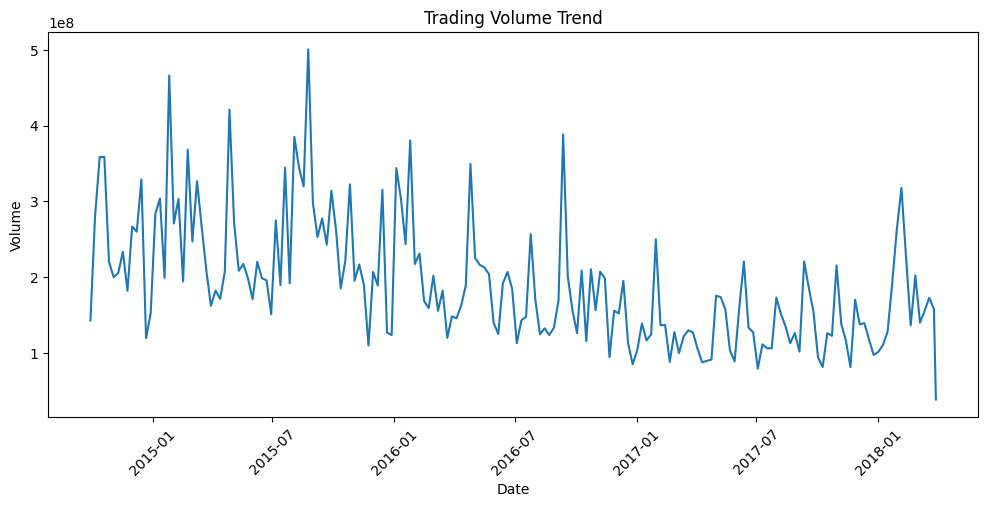

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Volume'])

plt.title('Trading Volume Trend')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.xticks(rotation=45)
plt.show()

In [10]:
average_volume = df['Volume'].mean()

print("Average Trading Volume:", average_volume)

Average Trading Volume: 191016776.11413044


In [11]:
volume_mean = df['Volume'].mean()
volume_std = df['Volume'].std()

volume_limit = volume_mean + (2 * volume_std)

anomalous_days = df[df['Volume'] > volume_limit]

print("Anomalous Trading Days:")
print(anomalous_days[['Date', 'Volume']])

Anomalous Trading Days:
          Date     Volume
2   2014-10-13  358539800
3   2014-10-20  358532900
17  2015-01-26  465842700
21  2015-02-23  368216200
30  2015-04-27  420972300
44  2015-08-03  385000600
47  2015-08-24  500363000
69  2016-01-25  380336500
102 2016-09-12  388228200


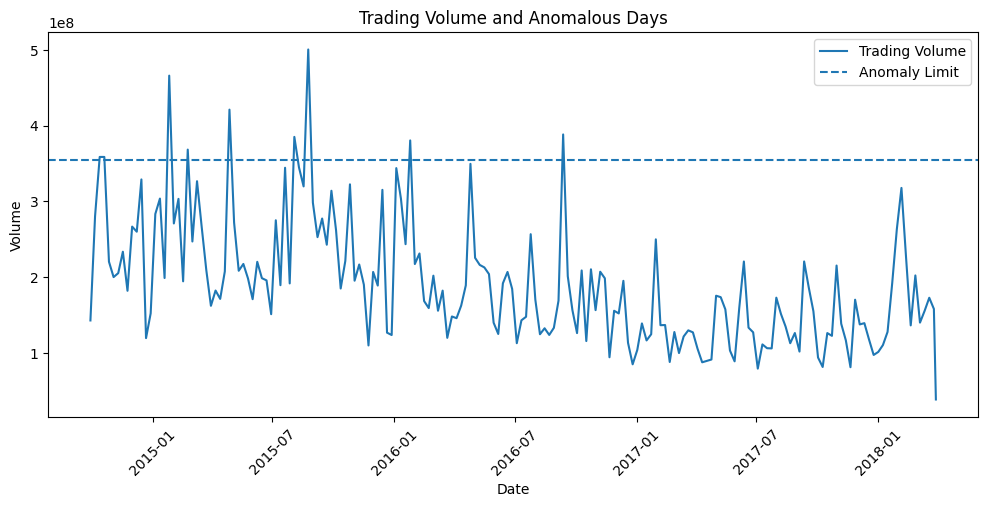

In [12]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Volume'], label='Trading Volume')

plt.axhline(volume_limit, linestyle='--', label='Anomaly Limit')

plt.title('Trading Volume and Anomalous Days')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.xticks(rotation=45)
plt.legend()
plt.show()

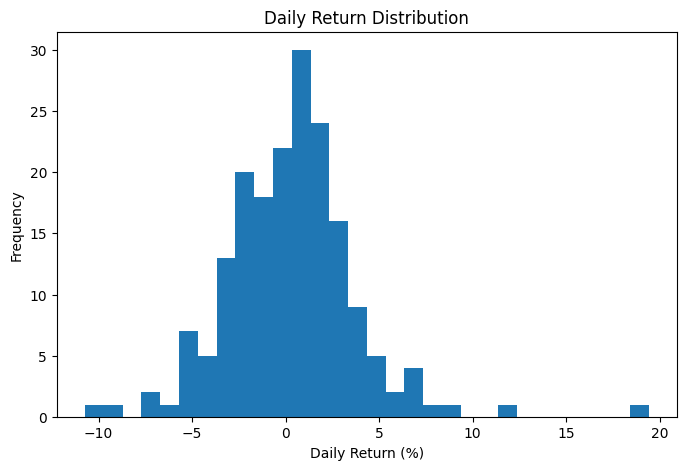

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df['Daily_Return'], bins=30)

plt.title('Daily Return Distribution')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')

plt.show()

In [14]:
mean_return = df['Daily_Return'].mean()
variance_return = df['Daily_Return'].var()
std_return = df['Daily_Return'].std()

print("Mean Return:", mean_return)
print("Variance:", variance_return)
print("Standard Deviation:", std_return)

Mean Return: 0.30716273695058094
Variance: 12.289199177244166
Standard Deviation: 3.5055954098047546


In [15]:
print("Stock Return Distribution Summary")
print("---------------------------------")
print("Mean Return:", round(mean_return, 4))
print("Variance:", round(variance_return, 4))
print("Standard Deviation:", round(std_return, 4))

Stock Return Distribution Summary
---------------------------------
Mean Return: 0.3072
Variance: 12.2892
Standard Deviation: 3.5056


In [16]:
df.head(10)

,Date,Open,High,Low,Close,Volume,Price_Delta,Daily_Return
0,2014-09-29,100.589996,100.690002,98.040001,99.620003,142718700,-0.969993,-0.964304
1,2014-10-06,99.949997,102.379997,98.309998,100.730003,280258200,0.780006,0.780396
2,2014-10-13,101.330002,101.779999,95.180000,97.669998,358539800,-3.660004,-3.611965
3,2014-10-20,98.320000,105.489998,98.220001,105.220001,358532900,6.900001,7.017902
4,2014-10-27,104.849998,108.040001,104.699997,108.000000,220230600,3.150002,3.004294
5,2014-11-03,108.220001,110.300003,107.720001,109.010002,199952900,0.790001,0.729995
6,2014-11-10,109.019997,114.190002,108.400002,114.180000,205166700,5.160003,4.733079
7,2014-11-17,114.269997,117.570000,113.300003,116.470001,233414700,2.200004,1.925268
8,2014-11-24,116.849998,119.750000,116.620003,118.930000,181873900,2.080002,1.780062
9,2014-12-01,118.809998,119.250000,111.269997,115.000000,266589700,-3.809998,-3.206799


In [17]:
df.to_csv('AAPL_cleaned.csv', index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
